<a href="https://colab.research.google.com/github/Prithviraj108/PUBG-Winner-Prediction-End-to-End-Machine-Learning-Project/blob/main/PUBG_Winner_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [4]:
## Scikit-learn libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
## XGBoost
from xgboost import XGBRegressor

Dataset URL: https://www.kaggle.com/datasets/prithvirajshukla/pubg-winner-prediction-dataset
License(s): apache-2.0
100% 244M/244M [00:12<00:00, 19.9MB/s]

Unzipping '/content/kaggle_data/pubg-winner-prediction-dataset/pubg-winner-prediction-dataset.zip'...
Unzipping complete.
Loading '/content/kaggle_data/pubg-winner-prediction-dataset/pubg.csv' into DataFrame...
DataFrame loaded successfully.
First 5 records:                Id         groupId         matchId  assists  boosts  \
0  7f96b2f878858a  4d4b580de459be  a10357fd1a4a91        0       0   
1  eef90569b9d03c  684d5656442f9e  aeb375fc57110c        0       0   
2  1eaf90ac73de72  6a4a42c3245a74  110163d8bb94ae        1       0   
3  4616d365dd2853  a930a9c79cd721  f1f1f4ef412d7e        0       0   
4  315c96c26c9aac  de04010b3458dd  6dc8ff871e21e6        0       0   

   damageDealt  DBNOs  headshotKills  heals  killPlace  ...  revives  \
0         0.00      0              0      0         60  ...        0   
1        91.47      

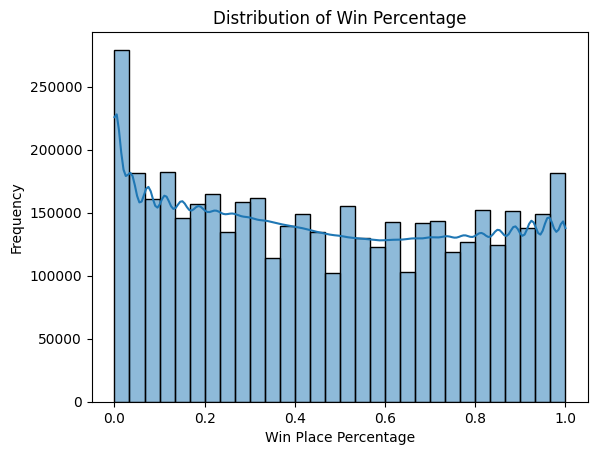

In [6]:
## Data Loading & Initial EDA
# Install Kaggle CLI tool if not already installed
!pip install kaggle

import pandas as pd
import os
import zipfile

# --- Kaggle API Authentication Instructions (REQUIRED for 403 errors) ---
# If you encountered a '403 Client Error', it means access to the dataset is denied.
# This typically requires you to authenticate with Kaggle using your API key.
# Follow these steps BEFORE running this cell:
# 1. Generate `kaggle.json`: Go to kaggle.com/[your_username]/account -> 'API' section -> 'Create New API Token'.
# 2. Upload `kaggle.json`: In Colab, use 'Files' icon (left sidebar) -> 'Upload to session storage' to upload your `kaggle.json` file.
# 3. Set up environment: Run the following commands in a *separate* cell or at the top of this one *after* uploading:
#    !mkdir -p ~/.kaggle
#    !cp kaggle.json ~/.kaggle/
#    !chmod 600 ~/.kaggle/kaggle.json
#    # Optional: Remove kaggle.json from the current directory after setup for security
#    # !rm kaggle.json
# -------------------------------------------------------------------

# Define the dataset and file within it
dataset_handle = "prithvirajshukla/pubg-winner-prediction-dataset"
file_in_dataset = "pubg.csv" # Changed from 'train.csv' to 'pubg.csv'

# Path for downloaded files
download_dir = "/content/kaggle_data"
# Create a specific directory for this dataset to avoid clutter
dataset_download_path = os.path.join(download_dir, dataset_handle.split('/')[-1])
os.makedirs(dataset_download_path, exist_ok=True)

# Download the dataset using Kaggle CLI
# This command assumes your Kaggle API key is correctly set up as described above.
print(f"Downloading dataset '{dataset_handle}' to '{dataset_download_path}'...")
!kaggle datasets download -d {dataset_handle} -p {dataset_download_path} --force

# Unzip the downloaded file(s)
zip_file_name = f"{dataset_handle.split('/')[-1]}.zip"
zip_file_path = os.path.join(dataset_download_path, zip_file_name)

if os.path.exists(zip_file_path):
    print(f"Unzipping '{zip_file_path}'...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_download_path)
    print("Unzipping complete.")
    # Optional: Remove the zip file after extraction
    # os.remove(zip_file_path)
else:
    print(f"Warning: Zip file '{zip_file_path}' not found. It might have been extracted directly or dataset is not a zip.")

# Load the specific CSV file into a DataFrame
csv_file_path = os.path.join(dataset_download_path, file_in_dataset)

if os.path.exists(csv_file_path):
    print(f"Loading '{csv_file_path}' into DataFrame...")
    df = pd.read_csv(csv_file_path)
    print("DataFrame loaded successfully.")
    print("First 5 records:", df.head())
else:
    print(f"Error: The file '{file_in_dataset}' was not found in the extracted dataset at '{dataset_download_path}'.")
    print("Please check the dataset contents on Kaggle to confirm the correct filename.")
    # You might want to list files in dataset_download_path here to help debugging:
    # !ls {dataset_download_path}
    print("Dataset Info:")
df.info()

print("\nDataset Head:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

sns.histplot(df['winPlacePerc'], bins=30, kde=True)
plt.title("Distribution of Win Percentage")
plt.xlabel("Win Place Percentage")
plt.ylabel("Frequency")
plt.show()


In [7]:
## Correlation heatmap
# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

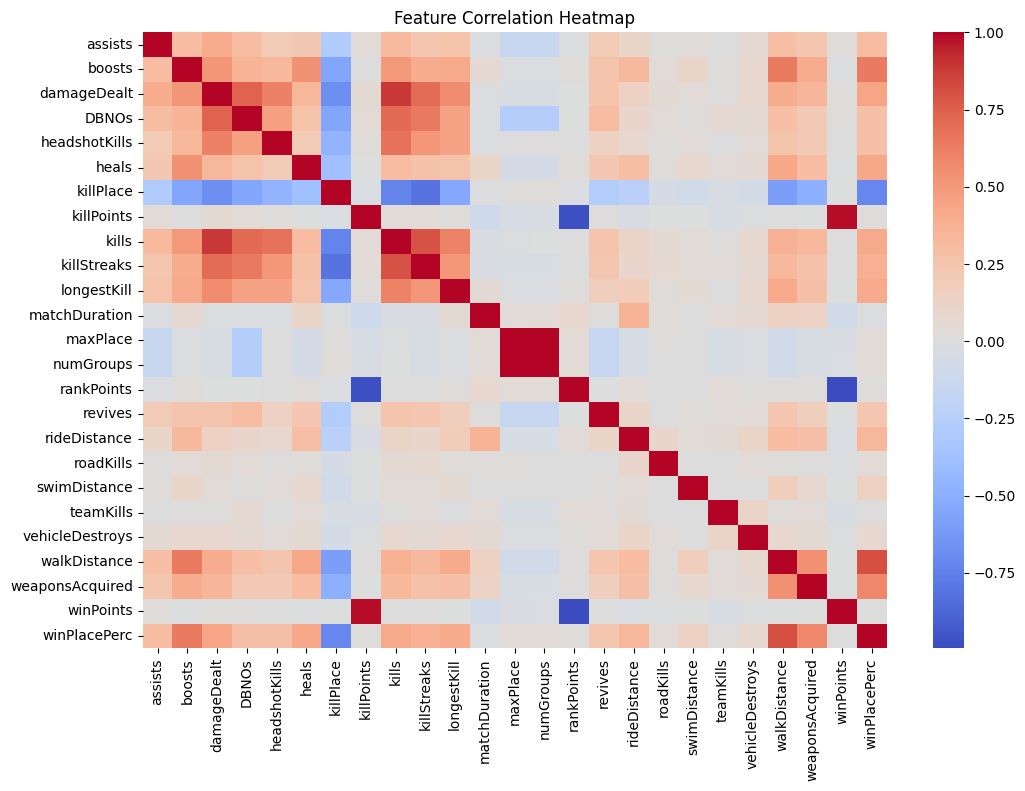

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
## Data Preprocessing
# Drop non-useful ID columns and separate target variable
X = df.drop(columns=['Id', 'groupId', 'matchId', 'winPlacePerc'])
y = df['winPlacePerc']

# One-hot encode categorical features
if 'matchType' in X.columns:
    X = pd.get_dummies(X, columns=['matchType'], drop_first=True)

In [10]:
## Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (3557572, 39)
Test set shape: (889394, 39)


In [11]:
## Outlier Detection & Removal (IQR Method)
def remove_outliers_iqr(df):
    # Convert boolean columns to int if any exist
    bool_cols = df.select_dtypes(include='bool').columns
    df = df.copy()
    for col in bool_cols:
        df[col] = df[col].astype(int)

    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Remove rows with any outlier values
    return df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

# Apply outlier removal to training data
X_train_cleaned = remove_outliers_iqr(X_train)
y_train_cleaned = y_train.loc[X_train_cleaned.index]
print("\nAfter Outlier Removal:")
print("X_train_cleaned shape:", X_train_cleaned.shape)
print("y_train_cleaned shape:", y_train_cleaned.shape)


After Outlier Removal:
X_train_cleaned shape: (605608, 39)
y_train_cleaned shape: (605608,)


In [12]:
## Feature Scaling
scaler = StandardScaler()
# Scale the cleaned training data
X_train_cleaned_scaled = scaler.fit_transform(X_train_cleaned)
# For evaluation, scale the test data using the original X_test (without outlier removal)
X_test_scaled = scaler.transform(X_test)
print("\nAfter Scaling:")
print("X_train_cleaned_scaled shape:", X_train_cleaned_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


After Scaling:
X_train_cleaned_scaled shape: (605608, 39)
X_test_scaled shape: (889394, 39)


In [13]:
## Model Training
print("\n=== Model Training (Default Parameters) ===")
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_cleaned_scaled, y_train_cleaned)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred)
    }
    print(f"Finished training {name}")

print("\nDefault Model Training Results:")
print(results)


=== Model Training (Default Parameters) ===
Training Linear Regression...
Finished training Linear Regression
Training Random Forest...
Finished training Random Forest
Training Gradient Boosting...
Finished training Gradient Boosting
Training XGBoost...
Finished training XGBoost

Default Model Training Results:
{'Linear Regression': {'MAE': 16.93547401004273, 'MSE': 2005.4692981257185, 'R2 Score': -21228.63570044992}, 'Random Forest': {'MAE': 0.07973154235468197, 'MSE': 0.01307956679023719, 'R2 Score': 0.8615414165971282}, 'Gradient Boosting': {'MAE': 0.08507537384299492, 'MSE': 0.013833403152454795, 'R2 Score': 0.8535614034587625}, 'XGBoost': {'MAE': 0.09368390992328514, 'MSE': 0.018245988905099594, 'R2 Score': 0.8068503477905484}}


In [14]:
## Hyperparameter Tuning (Using RandomizedSearchCV on a Sample)
print("\n=== Hyperparameter Tuning (RandomizedSearchCV) ===")
# Use a small sample for tuning to reduce computation time
X_sample = X_train_cleaned_scaled[:1000]
y_sample = y_train_cleaned[:1000]

# Random Forest tuning
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5, 10]
}

print("Starting RandomizedSearchCV for Random Forest on sample...")
randomized_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=3,
    cv=2,
    scoring='r2',
    n_jobs=1,
    verbose=2,
    random_state=42
)
start_time = time.time()
randomized_search_rf.fit(X_sample, y_sample)
end_time = time.time()
print(f"RandomizedSearchCV for Random Forest completed in {end_time - start_time:.2f} seconds.")
best_rf_model = randomized_search_rf.best_estimator_
print("Best Random Forest Model (tuned on sample):", best_rf_model)

# XGBoost tuning
param_dist_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 10]
}

print("Starting RandomizedSearchCV for XGBoost on sample...")
randomized_search_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=3,
    cv=2,
    scoring='r2',
    n_jobs=1,
    verbose=2,
    random_state=42
)
start_time = time.time()
randomized_search_xgb.fit(X_sample, y_sample)
end_time = time.time()
print(f"RandomizedSearchCV for XGBoost completed in {end_time - start_time:.2f} seconds.")
best_xgb_model = randomized_search_xgb.best_estimator_
print("Best XGBoost Model (tuned on sample):", best_xgb_model)


=== Hyperparameter Tuning (RandomizedSearchCV) ===
Starting RandomizedSearchCV for Random Forest on sample...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_split=10, n_estimators=200; total time=   0.7s
[CV] END max_depth=10, min_samples_split=10, n_estimators=200; total time=   0.7s
RandomizedSearchCV for Random Forest completed in 3.99 seconds.
Best Random Forest Model (tuned on sample): RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=200,
                      random_state=42)
Starting RandomizedSearchCV for XGBoost on sample...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] EN

In [15]:
## Refining the Hyperparameter Search Space
from sklearn.ensemble import RandomForestRegressor

param_dist_rf = {
    'n_estimators': [100, 150],  # narrowed range
    'max_depth': [10, 15, None],  # add a refined value
    'min_samples_split': [2, 3, 5]  # fewer options
}

from sklearn.model_selection import RandomizedSearchCV

randomized_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=5,
    cv=3,
    scoring='r2',
    n_jobs=1,
    verbose=2,
    random_state=42
)

randomized_search_rf.fit(X_train_cleaned_scaled, y_train_cleaned)
refined_rf_model = randomized_search_rf.best_estimator_
print("Refined Best Random Forest Model:", refined_rf_model)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 4.1min
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 4.2min
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time= 4.2min
[CV] END max_depth=10, min_samples_split=2, n_estimators=150; total time= 6.3min
[CV] END max_depth=10, min_samples_split=2, n_estimators=150; total time= 6.0min
[CV] END max_depth=10, min_samples_split=2, n_estimators=150; total time= 6.0min
[CV] END max_depth=15, min_samples_split=3, n_estimators=100; total time= 5.8min
[CV] END max_depth=15, min_samples_split=3, n_estimators=100; total time= 5.8min
[CV] END max_depth=15, min_samples_split=3, n_estimators=100; total time= 5.7min
[CV] END max_depth=10, min_samples_split=5, n_estimators=150; total time= 5.9min
[CV] END max_depth=10, min_samples_split=5, n_estimators=150; total time= 5.9min
[CV] END max_depth=10, min_samples_split=5, n_est

In [16]:
## Final Evaluation of Tuned Models
print("\n=== Final Evaluation on Test Data ===")
for name, model in {"Best Random Forest": best_rf_model, "Best XGBoost": best_xgb_model}.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))


=== Final Evaluation on Test Data ===

Best Random Forest Performance:
MAE: 0.0870057889943092
MSE: 0.014669996618627782
R2 Score: 0.8447053344414867

Best XGBoost Performance:
MAE: 0.09113226972060384
MSE: 0.01629887818736092
R2 Score: 0.8274622071915705


In [17]:
## Cross-Validation for Final Model Evaluation
from sklearn.model_selection import cross_val_score, KFold

# Choose your best model (for example, best_rf_model from hyperparameter tuning)
final_model = refined_rf_model

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate the model using cross-validation (using R2 as the scoring metric)
cv_scores = cross_val_score(final_model, X_train_cleaned_scaled, y_train_cleaned, cv=kf, scoring='r2')

print("Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2 Score:", cv_scores.mean())

Cross-Validation R2 Scores: [0.90978227 0.90830487 0.90906226 0.90891553 0.91023008]
Average CV R2 Score: 0.9092590016686936


In [18]:
## Save best model (based on R2 score)
# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Find best model based on R2 Score
best_model_name = results_df['R2 Score'].idxmax()
print(f"Best model selected: {best_model_name}")

                         MAE          MSE      R2 Score
Linear Regression  16.935474  2005.469298 -21228.635700
Random Forest       0.079732     0.013080      0.861541
Gradient Boosting   0.085075     0.013833      0.853561
XGBoost             0.093684     0.018246      0.806850
Best model selected: Random Forest


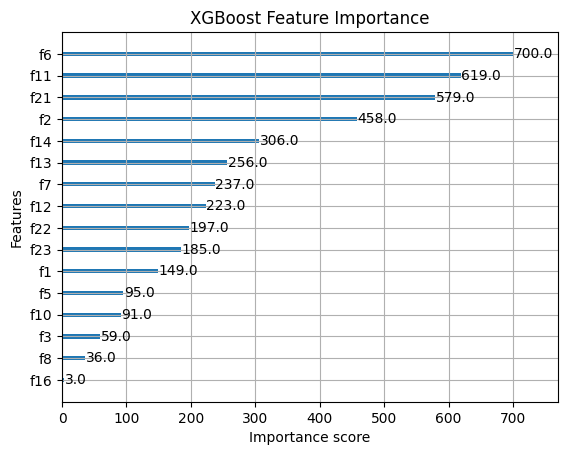

In [19]:
import xgboost as xgb
xgb.plot_importance(best_xgb_model)
plt.title("XGBoost Feature Importance")
plt.show()

          Feature  Importance
6       killPlace    0.690619
21   walkDistance    0.206064
9     killStreaks    0.031222
8           kills    0.018939
13      numGroups    0.016582
11  matchDuration    0.014642
12       maxPlace    0.008893
14     rankPoints    0.002530
2     damageDealt    0.002147
23      winPoints    0.001840


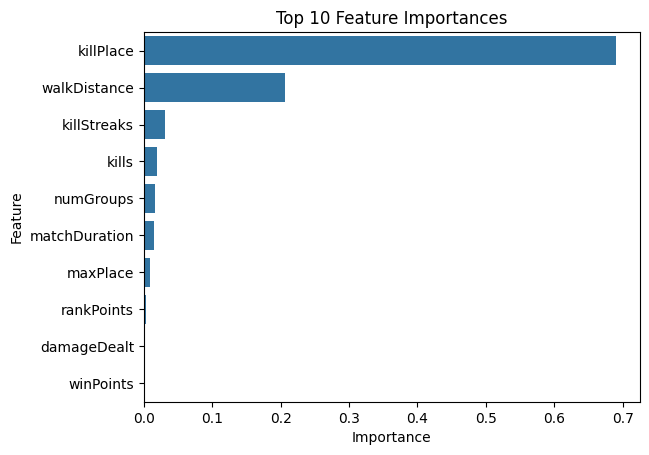

In [20]:
## Feature Importance Analysis
# For Random Forest or Gradient Boosting, you can access feature importances:
importances = refined_rf_model.feature_importances_
feature_names = X_train_cleaned.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))  # Print top 10 important features

# Optionally, plot the importances
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()

In [21]:
print("Challenges Faced:")
print("- Handling missing values.")
print("- Feature selection and engineering.")
print("- Choosing the right model for prediction.")
print("- Hyperparameter tuning and performance evaluation.")

Challenges Faced:
- Handling missing values.
- Feature selection and engineering.
- Choosing the right model for prediction.
- Hyperparameter tuning and performance evaluation.
